# 문과생을 위한 선형판별분석(LDA) — iris 실습 노트북

붓꽃(iris) 자료로 LDA 를 처음부터 끝까지 실행한다. 손계산은 하지 않고 `scikit-learn` 으로 검증한다.
표는 `polars` 로 본다.

> LDA 와 PCA 의 결정적 차이는 **라벨을 쓰느냐**이다. LDA 는 `fit_transform(Z, y)` 에 라벨 `y` 가 꼭 필요하다.

## 0. 준비 — 한글 글꼴 (그대로 실행)

In [1]:
import matplotlib.pyplot as plt, matplotlib.font_manager as fm
for _f in ["/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
           "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"]:
    try:
        fm.fontManager.addfont(_f)
        plt.rcParams["font.family"] = fm.FontProperties(fname=_f).get_name(); break
    except Exception:
        pass
plt.rcParams["axes.unicode_minus"] = False
print("글꼴 준비 완료")

글꼴 준비 완료


## 1. 자료 가져오기 — polars 표로 보기

In [2]:
import polars as pl
from sklearn.datasets import load_iris
iris = load_iris()
cols = ["꽃받침길이", "꽃받침너비", "꽃잎길이", "꽃잎너비"]
df = pl.DataFrame(iris.data, schema=cols)
df = df.with_columns(pl.Series("품종", [iris.target_names[i] for i in iris.target]))
df.head()

꽃받침길이,꽃받침너비,꽃잎길이,꽃잎너비,품종
f64,f64,f64,f64,str
5.1,3.5,1.4,0.2,"""setosa"""
4.9,3.0,1.4,0.2,"""setosa"""
4.7,3.2,1.3,0.2,"""setosa"""
4.6,3.1,1.5,0.2,"""setosa"""
5.0,3.6,1.4,0.2,"""setosa"""


## 2. 표준화 (그대로 실행)

In [3]:
from sklearn.preprocessing import StandardScaler
Z = StandardScaler().fit_transform(iris.data)
y = iris.target
print("자료:", Z.shape, "| 품종 수:", len(set(y)))

자료: (150, 4) | 품종 수: 3


## 3. LDA 적용 — 라벨 y 를 함께 넣는다

PCA 와 달리 LDA 는 라벨 `y` 가 반드시 들어간다. 이 한 줄이 핵심이다.

In [4]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis(n_components=2).fit(Z, y)
lds = lda.transform(Z)
print("LD 좌표 크기:", lds.shape)                  # (150, 2)
print("LD 축별 분리 기여:", lda.explained_variance_ratio_.round(4))

LD 좌표 크기: (150, 2)
LD 축별 분리 기여: [0.9912 0.0088]


LD1 이 품종 분리의 약 99%, LD2 가 약 1% 를 담당한다. 사실상 LD1 한 축으로 품종이 갈린다.

## 4. LD 스코어를 polars 표로

In [5]:
sc = pl.DataFrame(lds, schema=["LD1", "LD2"])
sc = sc.with_columns(pl.Series("품종", [iris.target_names[i] for i in iris.target]))
sc.head()

LD1,LD2,품종
f64,f64,str
8.0618,-0.300421,"""setosa"""
7.128688,0.78666,"""setosa"""
7.489828,0.265384,"""setosa"""
6.813201,0.670631,"""setosa"""
8.132309,-0.514463,"""setosa"""


## 5. LD1-LD2 평면에 세 품종 그리기

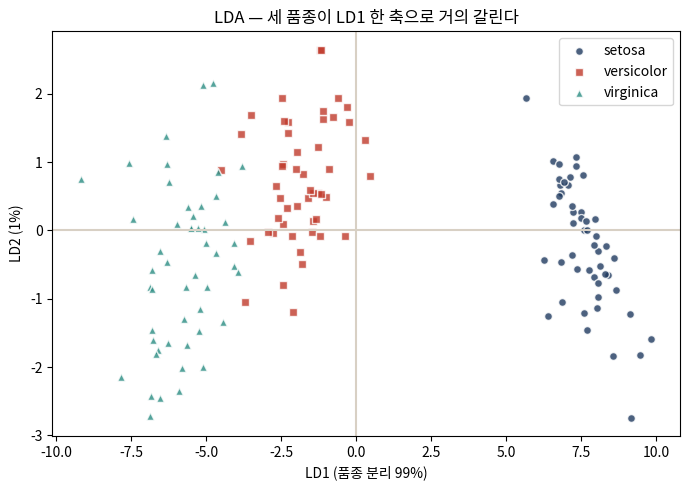

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
cmap = ["#1F3A5F", "#C0392B", "#2A8C82"]; marks = ["o", "s", "^"]
for k, name in enumerate(iris.target_names):
    m = y == k
    ax.scatter(lds[m, 0], lds[m, 1], c=cmap[k], marker=marks[k],
               s=32, alpha=0.8, edgecolor="white", label=name)
ax.axhline(0, color="#D8D0C4"); ax.axvline(0, color="#D8D0C4")
ax.set_xlabel("LD1 (품종 분리 99%)"); ax.set_ylabel("LD2 (1%)")
ax.set_title("LDA — 세 품종이 LD1 한 축으로 거의 갈린다"); ax.legend()
plt.tight_layout(); plt.show()

## 6. PCA 와 한 축으로 견주기

같은 자료를 PCA 한 축(PC1)과 LDA 한 축(LD1)으로 압축해 견준다.
PCA 는 라벨 없이, LDA 는 라벨과 함께 줄인다.

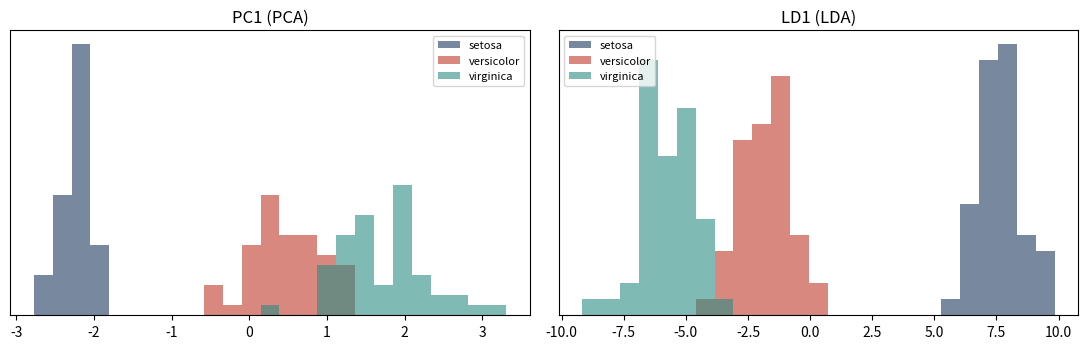

In [7]:
from sklearn.decomposition import PCA
import numpy as np
pc1 = PCA(n_components=2).fit_transform(Z)[:, 0]      # 라벨 안 씀
ld1 = lds[:, 0]                                        # 라벨 씀
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, data, name in zip(axes, [pc1, ld1], ["PC1 (PCA)", "LD1 (LDA)"]):
    bins = np.linspace(data.min(), data.max(), 26)
    for k in range(3):
        ax.hist(data[y == k], bins=bins, color=cmap[k], alpha=0.6, label=iris.target_names[k])
    ax.set_title(name); ax.set_yticks([]); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**해석** — PCA 한 축에서는 versicolor 와 virginica 가 가운데서 겹치지만,
LDA 한 축에서는 세 품종이 좌·중·우로 깔끔하게 갈린다. 라벨을 길잡이로 삼은 LDA 가
무리를 가르는 데 더 알맞다.